### Performance Metrics Clustering-Silhouetter Coefficient

In [31]:
from sklearn.datasets import make_blobs
# make_blobs() creates fake data that already looks like clusters, so we can test how well a clustering algorithm works.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


In [32]:
# make_blobs is used to generate synthetic (fake) clustered data
# This data is mainly used to test and understand clustering algorithms

# n_samples = 500
# → Total number of data points generated is 500

# n_features = 2
# → Each data point has 2 features (2D data, easy to visualize on a graph)

# centers = 4
# → Data is generated around 4 cluster centers
# → One cluster is clearly separated, while the other 3 are placed close together
# → This makes clustering slightly challenging and useful for evaluation

# cluster_std = 1
# → Standard deviation of clusters
# → Controls how spread out the points are around each cluster center
# → Smaller value = tight clusters, larger value = more overlap

# center_box = (-10.0, 10.0)
# → Cluster centers are randomly placed within this range on both axes

# shuffle = True
# → Data points from all clusters are randomly mixed
# → Points are NOT ordered as cluster 0, then 1, then 2, etc.

# random_state = 1
# → Ensures reproducibility
# → Running the code again will generate the same data

# X → Feature matrix containing coordinates of 500 data points
# y → True cluster labels (ground truth), mainly used for validation or plotting
# → In real clustering problems, y is usually NOT available

# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(n_samples=500,
                  n_features=2,
                  centers=4,
                  cluster_std=1,
                  center_box=(-10.0, 10.0),
                  shuffle=True,
                  random_state=1)

# range_n_clusters
# → List of different K values to try in K-Means clustering
# → Used to compare clustering performance (e.g., using Silhouette Score)
# → Helps find the optimal number of clusters

range_n_clusters = [2, 3, 4, 5, 6]


In [33]:
X

array([[-6.92324165e+00, -1.06695320e+01],
       [-8.63062033e+00, -7.13940564e+00],
       [-9.63048069e+00, -2.72044935e+00],
       [-2.30647659e+00,  5.30797676e+00],
       [-7.57005366e+00, -3.01446491e+00],
       [-1.00051011e+00,  2.77905153e+00],
       [-4.81826839e+00, -2.77214822e+00],
       [-5.33964799e+00, -1.27625764e+00],
       [-7.94308840e+00, -3.89993901e+00],
       [-5.54924525e+00, -3.41298968e+00],
       [-5.14508990e+00, -9.54492198e+00],
       [-7.09669936e+00, -8.04074036e+00],
       [-5.82641512e+00, -1.96346196e+00],
       [-1.83198811e+00,  3.52863145e+00],
       [-7.34267235e+00, -3.16546482e+00],
       [-7.34072825e+00, -6.92427252e+00],
       [-7.94653906e+00, -3.36768655e+00],
       [-8.24598536e+00, -8.61315821e+00],
       [-1.98197711e+00,  4.02243551e+00],
       [-4.35098035e+00, -3.69476678e+00],
       [-1.04768696e+01, -3.60318139e+00],
       [-1.10195984e+01, -3.15882031e+00],
       [-5.17255904e+00, -4.31835971e+00],
       [-2.

In [34]:
y

array([2, 2, 1, 0, 3, 0, 3, 3, 1, 3, 2, 2, 3, 0, 3, 2, 1, 2, 0, 3, 1, 1,
       3, 0, 3, 3, 0, 0, 1, 3, 2, 0, 3, 2, 3, 2, 1, 1, 2, 1, 3, 1, 0, 3,
       3, 2, 1, 3, 0, 0, 0, 1, 1, 3, 2, 1, 1, 1, 1, 3, 0, 0, 1, 3, 0, 3,
       2, 3, 1, 1, 2, 1, 3, 2, 3, 3, 2, 3, 3, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 2, 1, 3, 0, 2, 2, 3, 2, 0, 0, 2, 0, 1, 0, 3, 3, 0, 0, 1,
       3, 2, 0, 1, 0, 1, 0, 3, 0, 3, 1, 2, 2, 1, 3, 1, 0, 2, 2, 3, 0, 1,
       1, 1, 1, 2, 0, 3, 0, 0, 3, 2, 3, 0, 0, 0, 3, 3, 2, 2, 1, 1, 0, 2,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 2, 3, 0, 2, 1, 3, 2, 0, 1,
       1, 1, 1, 2, 3, 1, 0, 2, 2, 1, 3, 2, 2, 3, 0, 0, 2, 2, 3, 0, 3, 2,
       2, 0, 2, 1, 0, 3, 3, 2, 3, 1, 2, 3, 1, 3, 1, 2, 3, 3, 3, 0, 1, 0,
       3, 2, 1, 3, 1, 1, 1, 0, 3, 0, 2, 1, 2, 1, 0, 0, 1, 2, 0, 2, 3, 1,
       2, 2, 2, 2, 3, 1, 2, 1, 3, 0, 0, 3, 3, 0, 1, 3, 1, 0, 3, 0, 1, 1,
       0, 3, 2, 2, 1, 1, 1, 3, 0, 0, 3, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 0,
       0, 3, 1, 1, 1, 3, 3, 3, 2, 0, 2, 1, 2, 3, 2,

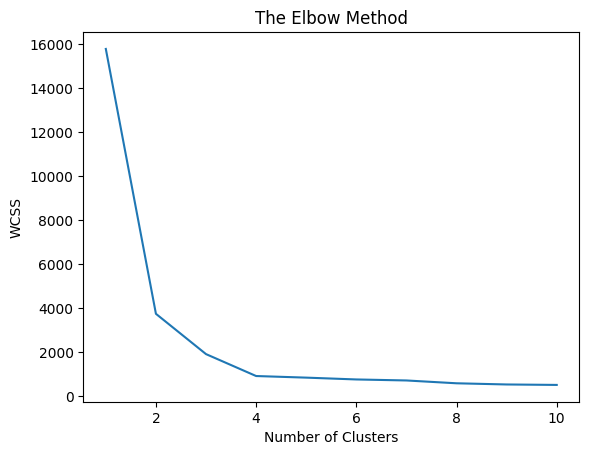

In [35]:
from sklearn.cluster import KMeans
# wcss -: within cluster sum of squares
wcss=[]
# Loop runs K-Means for cluster counts from k = 1 to 10
for i in range(1, 11):

    # Create K-Means model with i clusters
    # k-means++ initializes centroids smartly and far away from each other for faster and better convergence
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
#     Convergence means:
    # The K-Means algorithm has stopped changing because it has found stable cluster centroids.

    # In simple words:
    # Centroids no longer move
    # Cluster assignments no longer change
    # The algorithm says: “This is the best I can do”

    # Fit K-Means on dataset X
    kmeans.fit(X)

    # inertia_ gives WCSS (Within-Cluster Sum of Squares)
    # Lower WCSS means points are closer to their cluster centroids
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [36]:
# According to elbow curve-: Last abrupt change came at "4". So; optimal k value = 4
clusterer = KMeans(n_clusters=4, random_state=10)
# fit() → trains the model only (learns centroids), does NOT return labels
# fit_predict() → trains the model and returns cluster labels in one step
cluster_labels = clusterer.fit_predict(X)
print(cluster_labels)

[3 3 0 1 2 1 2 2 2 2 3 3 2 1 2 3 2 3 1 2 0 0 2 1 2 2 1 1 0 2 3 1 2 3 2 3 0
 0 3 0 2 0 1 2 2 3 0 2 1 1 1 0 0 2 3 0 0 0 0 2 1 1 0 2 1 2 3 2 0 0 3 0 2 3
 2 2 3 2 2 0 1 1 0 1 1 0 0 1 0 0 1 3 0 2 1 3 3 2 3 1 1 3 1 0 1 2 2 1 1 0 2
 3 1 0 1 0 1 2 1 2 0 3 3 0 2 0 1 3 3 2 1 0 0 0 0 3 1 2 1 1 2 3 2 1 1 1 2 2
 3 3 0 0 1 3 1 0 0 0 0 0 0 0 0 0 1 3 3 3 2 1 3 0 2 3 1 0 0 0 0 3 2 0 1 3 3
 0 2 3 3 2 1 1 3 3 2 1 2 3 3 1 3 0 1 2 2 3 2 0 3 2 0 2 0 3 2 2 2 1 0 1 2 3
 0 2 0 0 0 1 0 1 3 0 3 0 1 1 0 3 1 3 2 0 3 3 3 3 2 0 3 0 2 1 1 2 2 1 0 2 0
 1 2 1 0 0 1 2 3 3 0 0 0 2 1 1 2 1 0 3 1 3 1 3 3 1 3 1 1 2 0 0 0 2 2 0 3 1
 3 3 3 2 0 2 3 0 3 3 0 3 3 0 1 3 2 2 1 1 0 3 1 1 2 3 1 1 2 0 1 0 2 3 3 1 0
 3 2 1 1 2 2 2 3 2 1 1 0 1 1 1 1 3 3 2 1 0 2 3 1 0 1 2 1 0 2 0 1 2 2 3 1 3
 3 3 3 3 3 0 3 1 3 1 1 0 1 2 0 0 3 1 0 1 2 3 0 0 3 0 0 1 1 3 0 2 1 2 2 3 3
 2 3 0 0 3 0 3 0 1 3 1 0 2 1 0 2 1 3 2 1 1 0 2 0 2 3 1 3 2 1 3 3 3 0 1 2 3
 2 2 0 0 3 2 2 2 2 2 2 3 2 0 3 2 1 2 1 2 0 0 1 1 1 0 2 0 3 0 1 2 3 1 3 1 3
 2 1 1 3 0 2 3 0 0 0 3 2 

For n_clusters = 2 The average silhouette_score is : 0.7049787496083262
For n_clusters = 3 The average silhouette_score is : 0.5882004012129721
For n_clusters = 4 The average silhouette_score is : 0.6505186632729437
For n_clusters = 5 The average silhouette_score is : 0.561464362648773
For n_clusters = 6 The average silhouette_score is : 0.4857596147013469


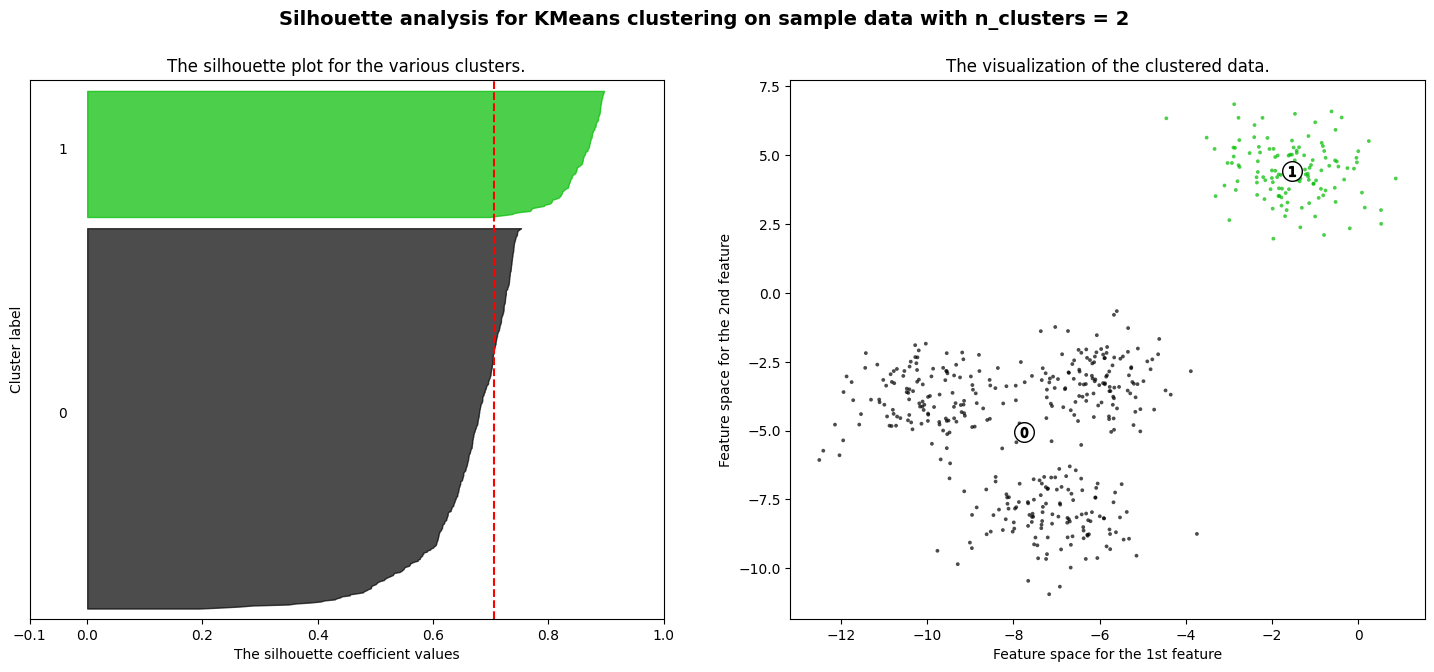

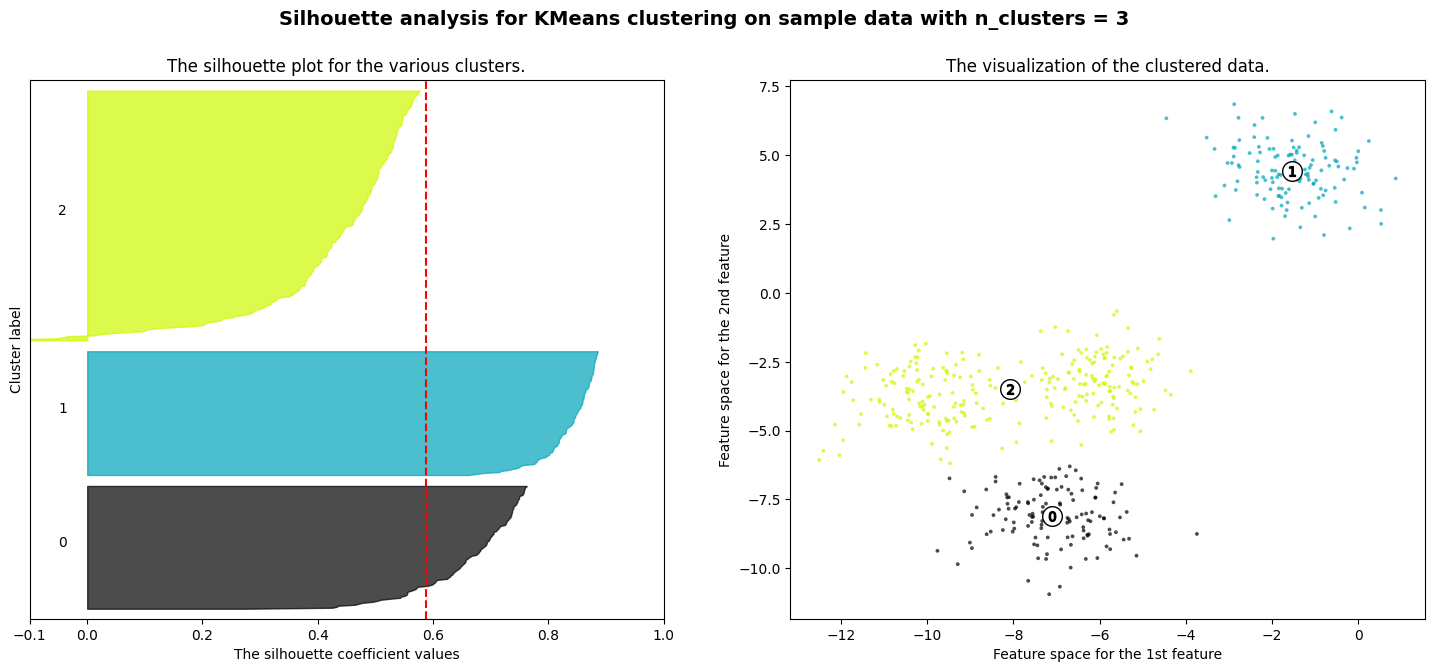

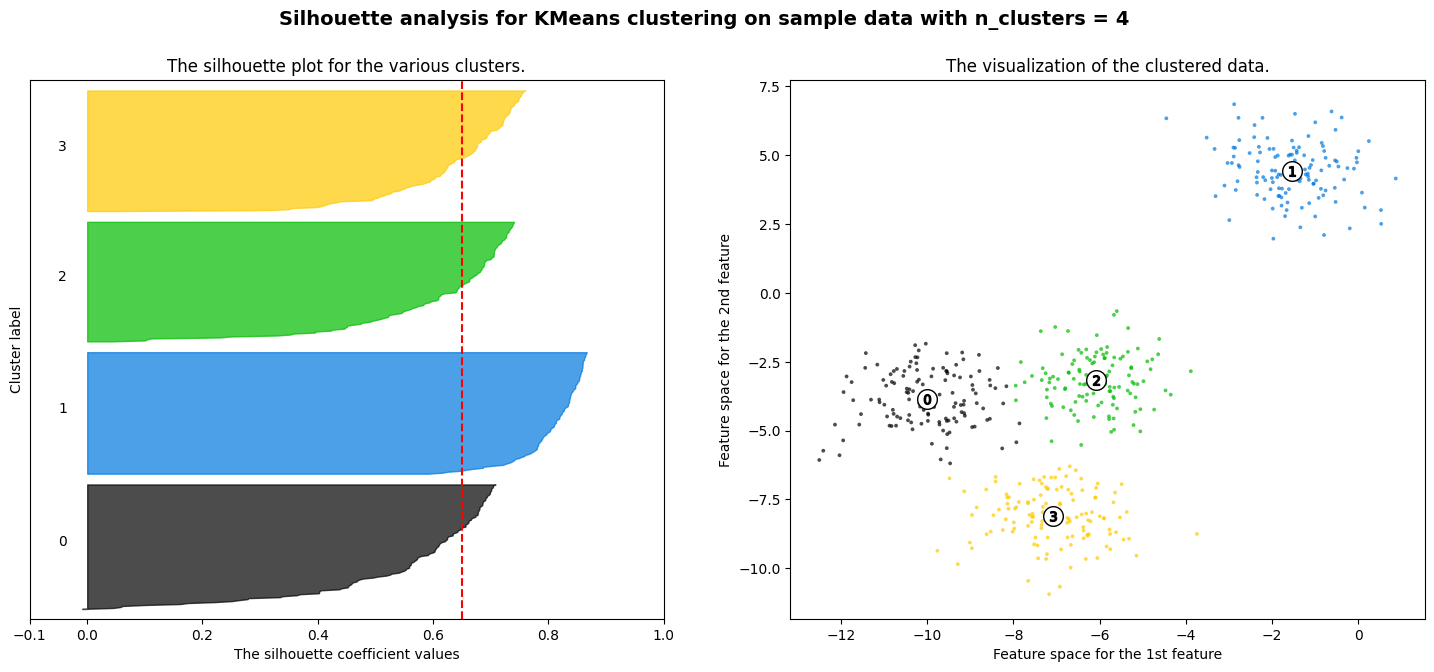

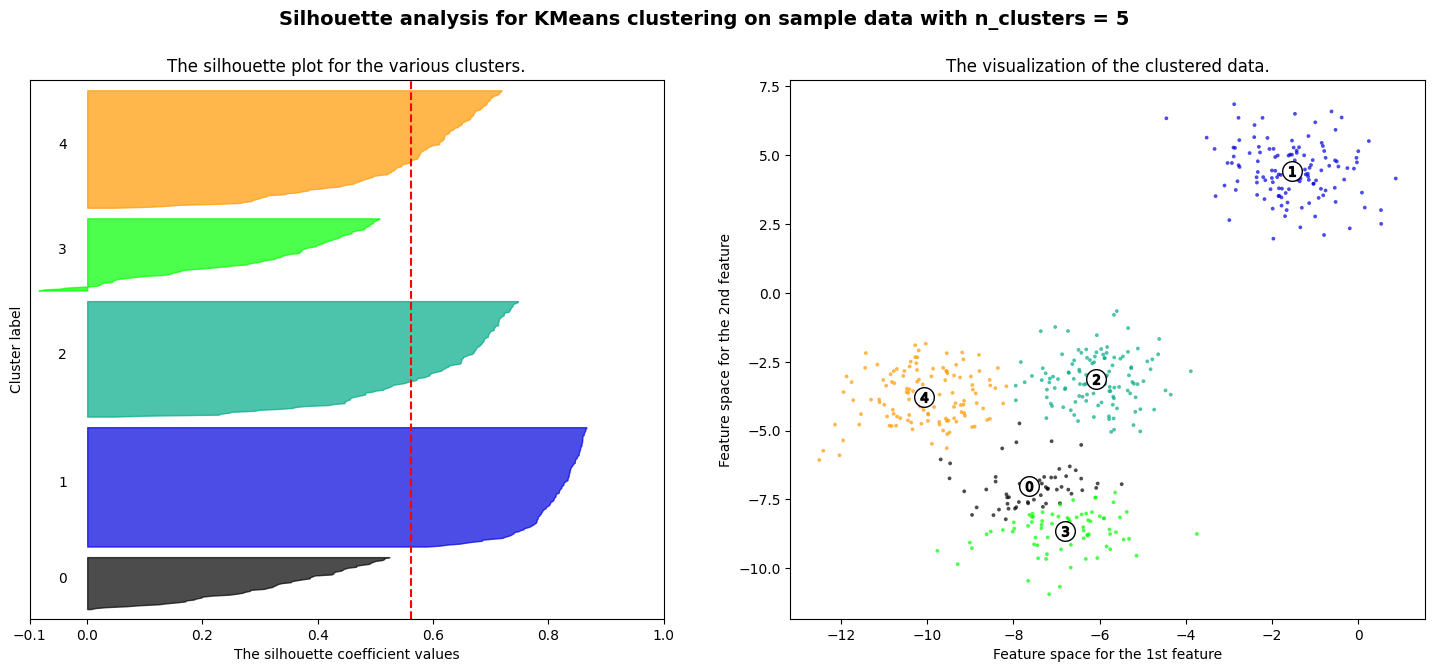

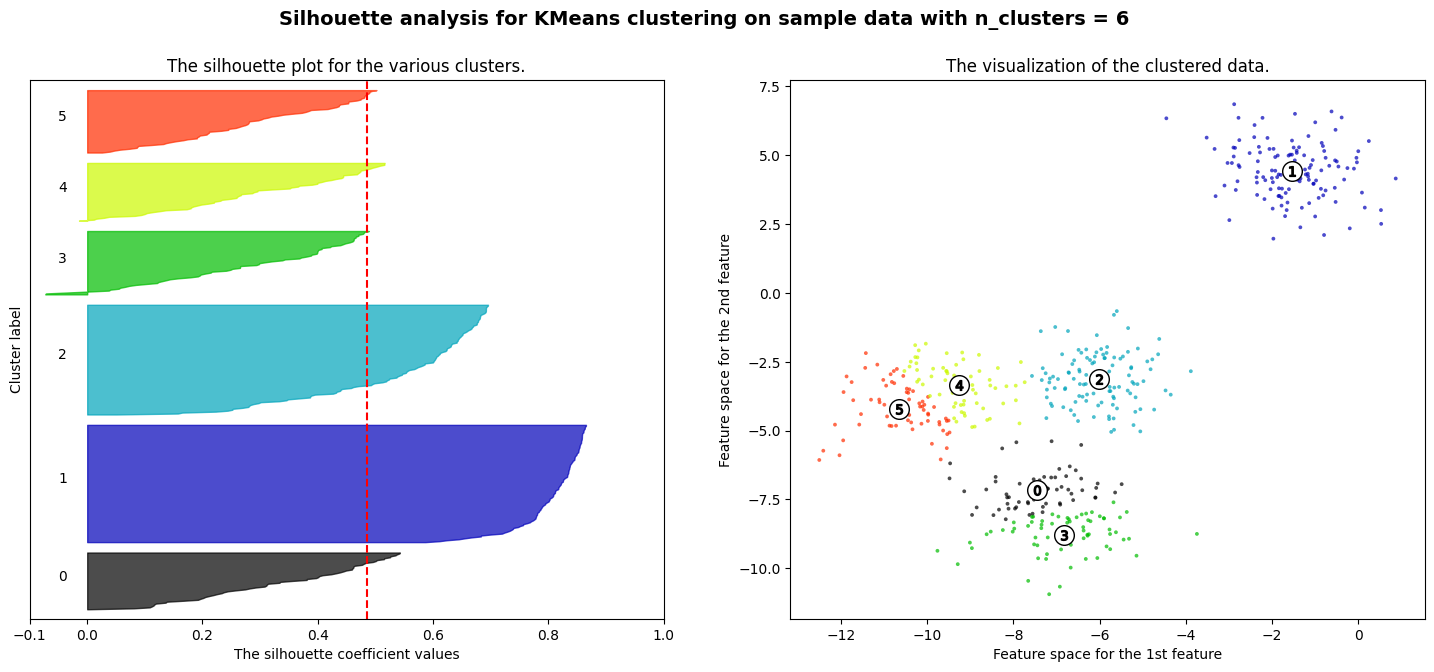

In [37]:
# Loop over different values of number of clusters (K)
# Used to evaluate clustering quality for multiple K values
for n_clusters in range_n_clusters:

    # Create a figure with 2 subplots (1 row, 2 columns)
    # Left plot → Silhouette plot (cluster quality)
    # Right plot → Cluster visualization (actual data distribution)
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # ---------------- LEFT PLOT: SILHOUETTE PLOT ----------------

    # Set x-axis limits for silhouette coefficient
    # Silhouette score ranges from -1 to +1
    ax1.set_xlim([-0.1, 1])

    # Set y-axis limit to fit all data points
    # Extra space ((n_clusters + 1) * 10) is added to clearly separate clusters
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize K-Means with current number of clusters
    # random_state ensures reproducible clustering results
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)

    # Fit the model and assign a cluster label to each data point
    cluster_labels = clusterer.fit_predict(X)

    # Compute the average silhouette score for all data points
    # Higher value → better cluster separation and compactness
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute silhouette score s(i) for each individual data point
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    # Initial vertical position for plotting silhouette bars
    y_lower = 10

    # Draw silhouette bars cluster-wise
    for i in range(n_clusters):

        # Extract silhouette scores of points belonging to cluster i
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        # Sort silhouette scores for better visualization
        ith_cluster_silhouette_values.sort()

        # Number of points in cluster i
        size_cluster_i = ith_cluster_silhouette_values.shape[0]

        # Upper y-axis boundary for this cluster
        y_upper = y_lower + size_cluster_i

        # Assign a unique color to each cluster
        color = cm.nipy_spectral(float(i) / n_clusters)

        # Draw horizontal bars for silhouette scores of cluster i
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the cluster number at the center of the silhouette bars
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Update y_lower for the next cluster
        # Extra gap (10 units) is added for clear separation
        y_lower = y_upper + 10

    # Set labels and title for silhouette plot
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # Draw a vertical red dashed line for average silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Remove y-axis ticks for cleaner visualization
    ax1.set_yticks([])

    # Set x-axis ticks for silhouette score scale
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # ---------------- RIGHT PLOT: CLUSTER VISUALIZATION ----------------

    # Assign colors to points based on their cluster labels
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    # Plot data points in feature space, colored by cluster
    ax2.scatter(X[:, 0], X[:, 1],
                marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Get cluster centroids from K-Means
    centers = clusterer.cluster_centers_

    # Plot centroids as white circles
    ax2.scatter(centers[:, 0], centers[:, 1],
                marker='o', c="white", alpha=1,
                s=200, edgecolor='k')

    # Label each centroid with its cluster index
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1],
                    marker='$%d$' % i,
                    alpha=1, s=50, edgecolor='k')

    # Set labels and title for cluster visualization plot
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    # Overall title for both plots showing current K value
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

# Display all plots
plt.show()


In [38]:
# Just because a model has better average Silhouette Score (k=2) that does NOT mean we should select it directly we should also check whether silhouette socre of each data point for that particular k-value is posiitve or NOT. If negative values of any silhouette score is there then we should use next optimal k-value.

# Here both k=2 and k=4 has good average silhouette score and all scihouette scores of each data point is positive for both k values.Then in this case it is better to pick a higher k-value even if avg. sihouette score of k=2 is more than k=4 cause higher k value means more clusters and It will help in creating a MORE GENERALIZED model. Also; the elbow method curve is also saying k=4 is the best optimal K-value. 

# K=4 is selelcted.

In [39]:
# LEFT PLOT (Silhouette Plot):
# Shows the silhouette score s(i) for each data point, grouped by cluster
# Each horizontal bar represents one data point
# Bar length indicates how well the point fits in its assigned cluster
# Values close to +1 → well clustered, near 0 → overlapping, negative → misclassified
# Red dashed vertical line represents the average silhouette score of all points
# Used to evaluate overall clustering quality

# RIGHT PLOT (Cluster Visualization):
# Shows the actual data points in feature space after clustering
# Each point is colored according to its assigned cluster
# White circles represent cluster centroids
# Used for visual inspection of cluster separation and shape
